In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
import xgboost as xgb
import lightgbm as lgb

url = "https://raw.githubusercontent.com/ankita1112/House-Prices-Advanced-Regression/master/train.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


EDA

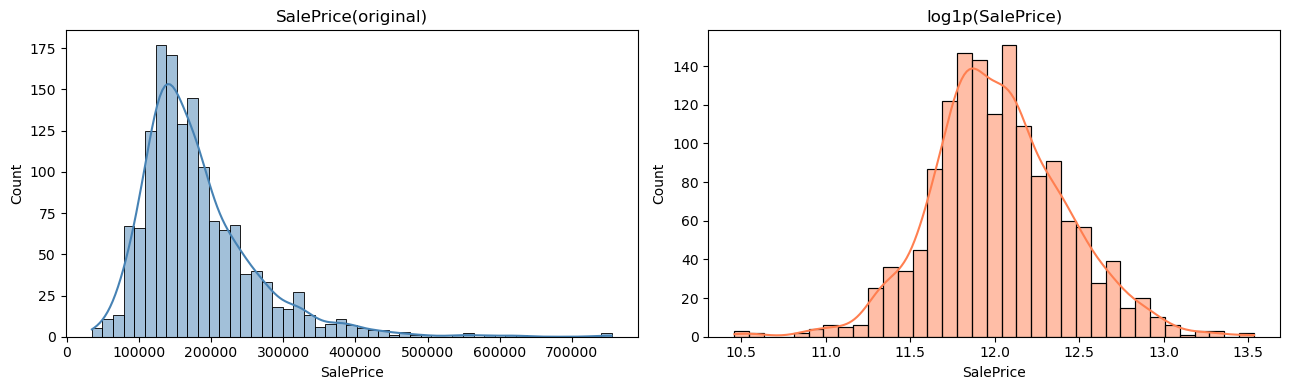

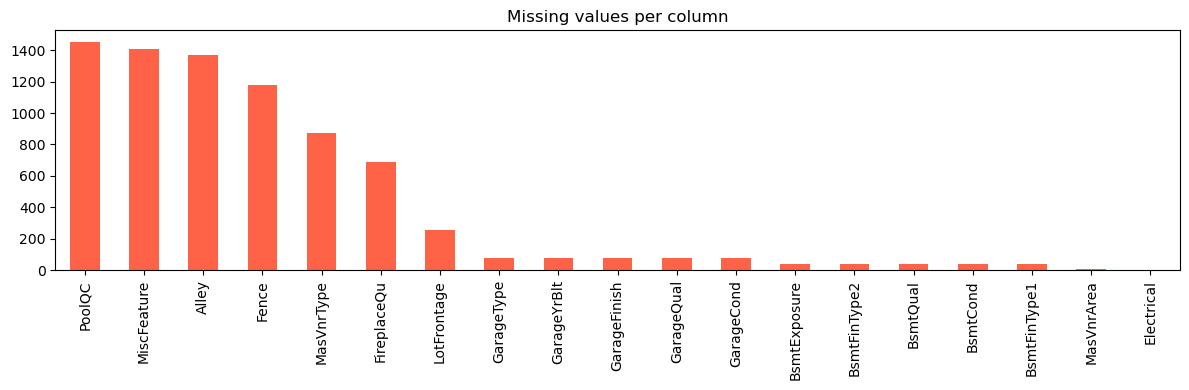

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice(original)')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('log1p(SalePrice)')
plt.tight_layout()
plt.show()

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(12, 4))
missing.plot.bar(color='tomato')
plt.title('Missing values per column')
plt.tight_layout()
plt.show()

In [ ]:
# prepearing test/train
test_url = "https://raw.githubusercontent.com/ankita1112/House-Prices-Advanced-Regression/master/test.csv"
test_raw = pd.read_csv(test_url)
train_id = df['Id']
test_id  = test_raw['Id']

y = np.log1p(df['SalePrice'])

train = df.drop(['Id', 'SalePrice'], axis=1).copy()
test  = test_raw.drop('Id', axis=1).copy()
n_train  = train.shape[0]
all_data = pd.concat([train, test], axis=0, ignore_index=True)
print(f'Train: {train.shape} Test: {test.shape}  Combined: {all_data.shape}')

Train: (1460, 79) Test: (1459, 79)  Combined: (2919, 79)


Outlier removal

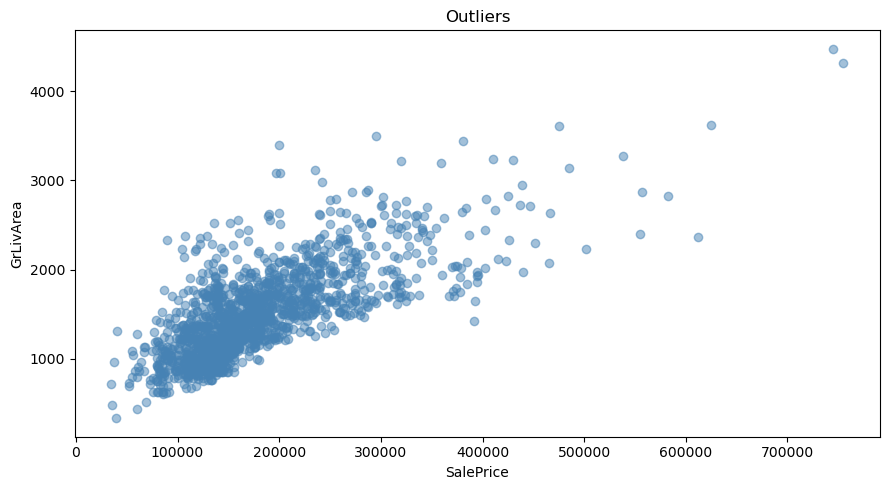

Removed outliers: []
After removing outliers — Train: (1458, 79)


In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(np.expm1(y), train['GrLivArea'], alpha=0.5, color='steelblue')
plt.xlabel('SalePrice')
plt.ylabel('GrLivArea')
plt.title('Outliers')
plt.tight_layout()
plt.show()

outlier_idx = train[(train['GrLivArea'] > 4000) & (np.expm1(y) < 300_000)].index
print(f'Removed outliers: {list(outlier_idx)}')

train.drop(outlier_idx, inplace=True)
y.drop(outlier_idx, inplace=True)
y.reset_index(drop=True, inplace=True)
train.reset_index(drop=True, inplace=True)

n_train  = train.shape[0]
all_data = pd.concat([train, test], axis=0, ignore_index=True)
print(f'After removing outliers — Train: {train.shape}')

In [7]:
none_cols = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

zero_cols = [
    'GarageYrBlt','GarageArea','GarageCars',
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath','BsmtHalfBath','MasVnrArea'
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

mode_cols = ['MSZoning','Electrical','KitchenQual','Exterior1st',
             'Exterior2nd','SaleType','Functional','Utilities']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

remaining = all_data.isnull().sum()
print('Remaining NaN values', remaining[remaining > 0].to_dict())

Remaining NaN values {}


Feature engineering

In [ ]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalLivingArea'] = all_data['GrLivArea']+ all_data['TotalBsmtSF']
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch']  + all_data['ScreenPorch'])
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['HouseAge'] = all_data['YrSold'].astype(int) - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'].astype(int) - all_data['YearRemodAdd']
all_data['GarageAge'] = (all_data['YrSold'].astype(int) - all_data['GarageYrBlt']).clip(lower=0)
all_data['IsNew'] = (all_data['YearBuilt'] == all_data['YrSold'].astype(int)).astype(int)
all_data['WasRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['QualSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['QualGrLiv'] = all_data['OverallQual'] * all_data['GrLivArea']
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
for col in ['ExterQual','KitchenQual','BsmtQual','GarageQual','FireplaceQu','PoolQC']:
    all_data[col + '_num'] = all_data[col].map(qual_map).fillna(0)
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea']  > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces']  > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)

print(f'num of all features: {all_data.shape[1]}')

num of all features: 101


Encoding

In [9]:
all_data = pd.get_dummies(all_data)
print(f'After encoding {all_data.shape}')

X_train = all_data[:n_train].values
X_test  = all_data[n_train:].values

print(f'X_train: {X_train.shape} X_test: {X_test.shape}')

After encoding (2917, 353)
X_train: (1458, 353) X_test: (1459, 353)


Grid search with XGBoost

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model, X, y):
    return -cross_val_score(
        model, X, y,
        scoring='neg_root_mean_squared_error',
        cv=kf, n_jobs=-1
    )
def report(name, scores):
    print(f'{name:<22} RMSE: {scores.mean():.5f} ± {scores.std():.5f}')
xgb_grid = {
    'n_estimators':     [500, 1000],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.01, 0.05],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.5, 0.7],
    'min_child_weight': [1, 3],
}

xgb_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid=xgb_grid,
    scoring='neg_root_mean_squared_error',
    cv=kf, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y)

print('Best XGB params:', xgb_search.best_params_)
print(f'Best XGB CV RMSE: {-xgb_search.best_score_:.5f}')
best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 1000, 'subsample': 0.7}
Best XGB CV RMSE: 0.11466


Grid search with LightGBM

In [12]:
lgb_grid = {
    'n_estimators':      [500, 1000],
    'max_depth':         [3, 4, 5],
    'learning_rate':     [0.01, 0.05],
    'num_leaves':        [31, 63]
}

lgb_search = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid=lgb_grid,
    scoring='neg_root_mean_squared_error',
    cv=kf, n_jobs=-1, verbose=1
)
lgb_search.fit(X_train, y)

print('Best LGB params:', lgb_search.best_params_)
print(f'Best LGB CV RMSE: {-lgb_search.best_score_:.5f}')
best_lgb = lgb_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best LGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'num_leaves': 31}
Best LGB CV RMSE: 0.12075


Model comparison

XGBoost                RMSE: 0.11466 ± 0.00522
LightGBM               RMSE: 0.12075 ± 0.00851


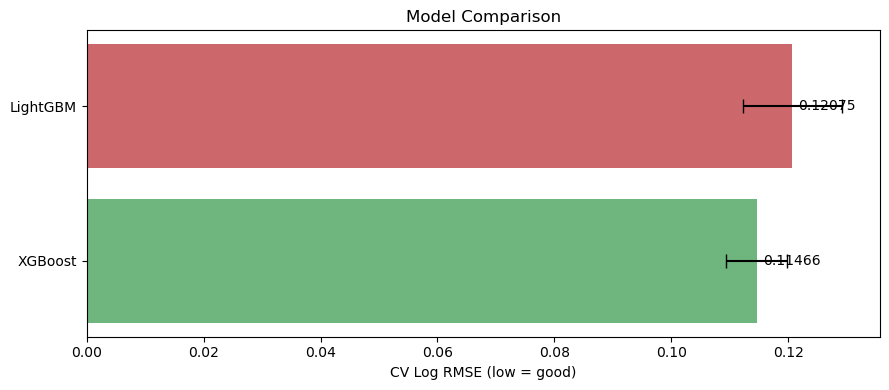

In [19]:
ridge = Ridge(alpha=10)

results = {
    'XGBoost':  rmse_cv(best_xgb, X_train, y),
    'LightGBM': rmse_cv(best_lgb, X_train, y)
}
for name, scores in results.items():
    report(name, scores)

fig, ax = plt.subplots(figsize=(9, 4))
names  = list(results.keys())
means  = [v.mean() for v in results.values()]
stds   = [v.std()  for v in results.values()]
colors = ['#55A868', '#C44E52']
bars   = ax.barh(names, means, xerr=stds, color=colors, alpha=0.85, capsize=5)
for bar, val in zip(bars, means):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=10)
ax.set_xlabel('CV Log RMSE (low = good)')
ax.set_title('Model Comparison')
plt.tight_layout()
plt.show()

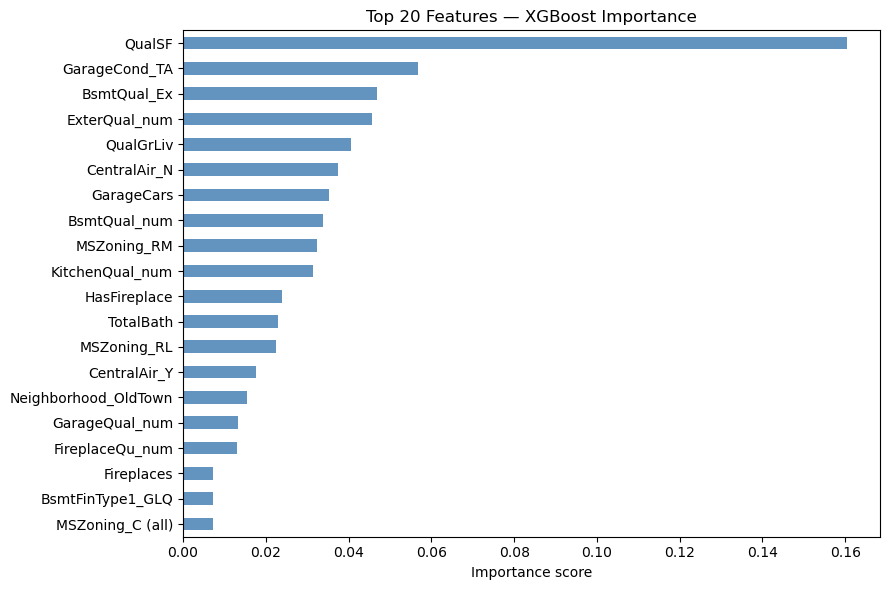

In [20]:
importance = pd.Series(
    best_xgb.feature_importances_,
    index=all_data.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot.barh(ax=ax, color='steelblue', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 20 Features — XGBoost Importance')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()